In [1]:
%matplotlib widget
import numpy as np
import tomllib
from pathlib import Path

from thesis_code.plotting import plot_performance, plot_gradients, plot_weight_matrices, InteractiveSpikePlot

In [2]:
work_dir = Path.cwd()
print(work_dir)
with open(work_dir / "config.toml", 'rb') as cfg_file:
    cfg = tomllib.load(cfg_file)

n_trials = cfg["training"]["n_trials"]
def get_data(data_group: str, data_name: str) -> np.ndarray:
    return np.array([np.load(work_dir / f"seed_{i}" / "data_net" / data_group / data_name) for i in range(n_trials)])

c:\Users\emiel\Documents\Study\Thesis\Thesis-Code\outputs\2026-10-09_09-46-36-test_weights_evolution_daleslaw


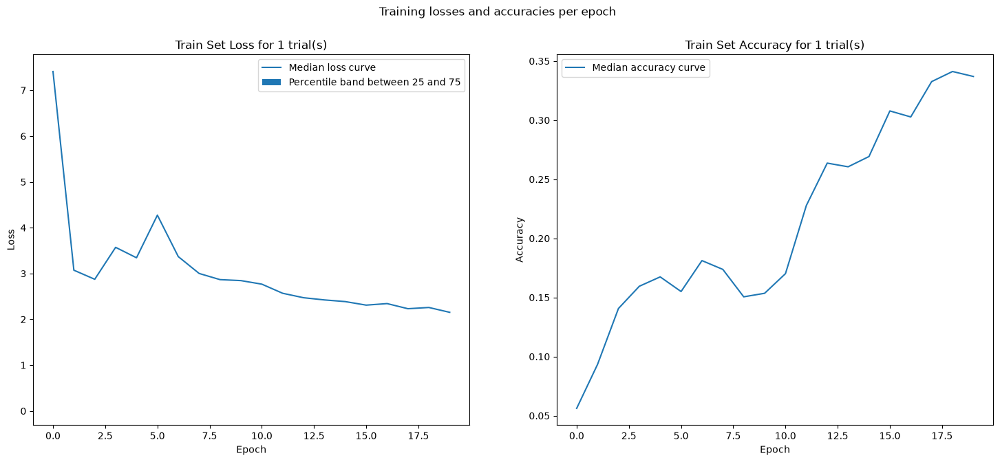

In [3]:
loss_rec = get_data("performance", "loss.npy")
acc_rec = get_data("performance", "acc.npy")
plot_performance(loss_rec, acc_rec)

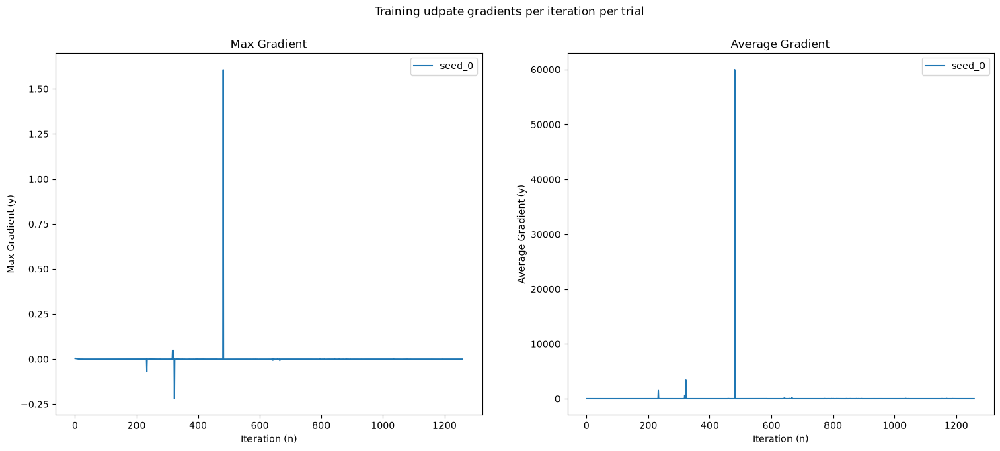

In [4]:
max_grad_rec = get_data("gradients", "avg_grad.npy")
avg_grad_rec = get_data("gradients", "max_grad.npy")
plot_gradients(max_grad_rec, avg_grad_rec)







In [ ]:
weights_forward_0 = get_data("weights", "weights_forward_0.npy")
plot_weight_matrices(weights_forward_0, name="weights_forward_0")

weights_forward_1 = get_data("weights", "weights_forward_1.npy")
plot_weight_matrices(weights_forward_1, name="weights_forward_1")

weights_recurrent_0 = get_data("weights", "weights_recurrent_0.npy")
plot_weight_matrices(weights_recurrent_0, name="weights_recurrent_0")

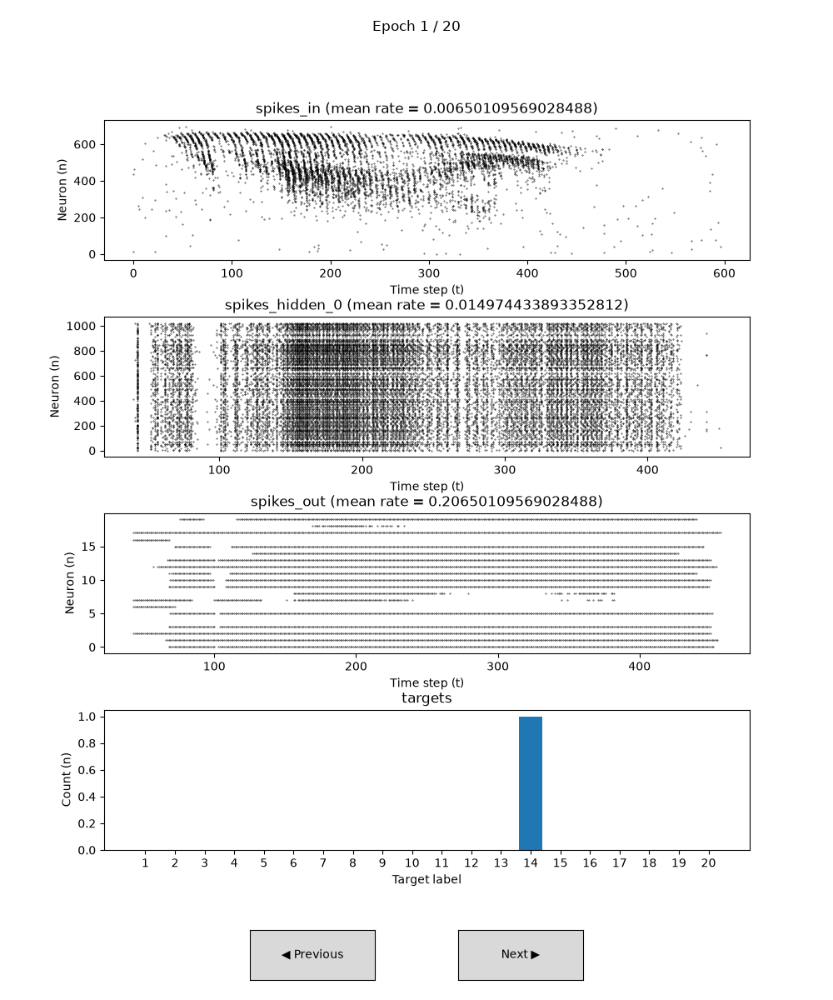

In [3]:
layer_spikes = {
    "spikes_in": get_data("spikes", "spikes_in.npy")[0],
    "spikes_hidden_0": get_data("spikes", "spikes_hidden_0.npy")[0],
    "spikes_out": get_data("spikes", "spikes_out.npy")[0],
    "targets": get_data("spikes", "targets.npy")[0],
}
isp = InteractiveSpikePlot(layer_spikes, range(1, 21))
# isp.draw()
isp.save_as_pdf()